*BERT model on Imbalanced data*

This notebook presents training the pretrained BERT on imbalanced dataset.To ensure uniformity, as this is a comparative analysis study,the same data preprocessing and preparation techniques are applied across all experiments.

In [ ]:
##importing necesaary libraries
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import tensorflow as tf
from transformers import BertTokenizer, TFBertForSequenceClassification, create_optimizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from tensorflow.keras.callbacks import EarlyStopping

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')




[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Loading the dataset
data = pd.read_csv('Service_tickets.csv')
data.head()


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [ ]:
data = pd.read_csv('Service_tickets.csv')
data.shape

(47837, 2)

In [ ]:
# checking the count of the frequency of the Classes
data['Topic_group'].value_counts()

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

**Data Cleaning and Encoding the Category Labels**

This step involves removing  non-alphabetic characters, Converting text to lowercase and removing stop words.
Also the target variable , topic groups is encoded  into numeric codes for prepration for the models.

In [ ]:
# Cleaning the text data
def clean_text(text):
    stop_words = set(stopwords.words('english'))
    text = text.lower()
    text = re.sub('[^a-zA-Z\s]', '', text)
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

data['Cleaned_Document'] = data['Document'].apply(clean_text)

# Ensuring the DataFrame has the columns i need
data = data[['Cleaned_Document', 'Topic_group']]

# Encode category labels using category codes
data["encoded_label"] = data["Topic_group"].astype('category').cat.codes

Data Preparation for BERT: Splitting, Tokenization, and Encoding

The  Data is split into Training and Test Sets using stratified spliting to ensure the class  distribution in the training and test sets represents the overall class distribution in the dataset.A further Split of the train data into train and validation Sets for validationg the model and for hyperparameter tuning during training.The test split is reserved for model evaluation after training.

BertTokenizer is used  for tokenizing the text data by converting them into tokenized sequences, and theyre truncated if longer than 512 tokens set limit,
Padding is done for texts shorter than 512tokens to have equal lenght for the sequences.

Converted the train,test and validation sets labels and the tokenized encodings to Numpy arrays for compatitbilty with tensorflow libraries  and also facilitate efficient batch processing and manipulation and Computation efficiency.


In [ ]:
# Split the data into training (80%) and test (20%) sets
train_data, test_data = train_test_split(data, test_size=0.2, stratify=data['Topic_group'], random_state=42)

# Further split the training data into training and validation sets (80% training, 20% validation)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_data['Cleaned_Document'].tolist(),
    train_data['encoded_label'].tolist(),
    test_size=0.2,  # This is 20% of the 80% training data, effectively 16% of the original data
    stratify=train_data['encoded_label'],
    random_state=42
)

# Tokenizing the texts
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=512)
test_encodings = tokenizer(test_data['Cleaned_Document'].tolist(), truncation=True, padding=True, max_length=512)


#Converting to NumPy Arrays
train_labels = np.array(train_labels)
val_labels = np.array(val_labels)
test_labels = np.array(test_data['encoded_label'].tolist())

train_encodings = {key: np.array(train_encodings[key]) for key in train_encodings}
val_encodings = {key: np.array(val_encodings[key]) for key in val_encodings}
test_encodings = {key: np.array(test_encodings[key]) for key in test_encodings}


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Loading,compiling and training the BERT Model

In [ ]:
# Loading and compiling BERT model
model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(data['Topic_group'].unique()))

# Defining hyperparameters
initial_learning_rate = 2e-5
number_epochs = 10
batch_size_train = 16
batch_size_val = 64
steps_per_epoch = len(train_encodings['input_ids']) // batch_size_train
number_train_steps = steps_per_epoch * number_epochs
warmup_steps = 500

# Creating optimizer
optimizer, schedule = create_optimizer(
    init_lr=initial_learning_rate,
    num_train_steps=number_train_steps,
    num_warmup_steps=warmup_steps
)

# Compiling the model
model.compile(optimizer=optimizer, loss=model.hf_compute_loss, metrics=['accuracy'])

# Converting encodings to TensorFlow datasets and batch them
train_dataset = tf.data.Dataset.from_tensor_slices((train_encodings, train_labels)).shuffle(len(train_labels)).batch(batch_size_train)
val_dataset = tf.data.Dataset.from_tensor_slices((val_encodings, val_labels)).batch(batch_size_val)
test_dataset = tf.data.Dataset.from_tensor_slices((test_encodings, test_labels)).batch(batch_size_val)

# Adding early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Training the model with validation data
history = model.fit(train_dataset, validation_data=val_dataset, epochs=num_epochs, callbacks=[early_stopping])

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/10


Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
1914/1914 [==============================] - 967s 465ms/step - loss: 0.8000 - accuracy: 0.7305 - val_loss: 0.4356 - val_accuracy: 0.8505
Epoch 2/10
1914/1914 [==============================] - 879s 459ms/step - loss: 0.3460 - accuracy: 0.8841 - val_loss: 0.3847 - val_accuracy: 0.8690
Epoch 3/10
1914/1914 [==============================] - 879s 459ms/step - loss: 0.2241 - accuracy: 0.9247 - val_loss: 0.4324 - val_accuracy: 0.8605
Epoch 4/10
1914/1914 [==============================] - 878s 459ms/step - loss: 0.1368 - accuracy: 0.9540 - val_loss: 0.4409 - val_accuracy: 0.8768
Epoch 5/10
1914/1914 [==============================] - 879s 459ms/step - loss: 0.0811 - accuracy: 0.9742 - val_loss: 0.5430 - val_accuracy: 0.8665


Model Evaluation on Test Set and Performance Metrics,confussion matrix and classifcation report

In [ ]:
# Evaluating the model on the test set
preds = model.predict(test_dataset)
y_pred = np.argmax(preds.logits, axis=-1)
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Computing metrics
conf_matrix = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc}")
print(f"F1 Score: {f1}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

# Generating classification report
class_report = classification_report(y_true, y_pred, target_names=data["Topic_group"].astype('category').cat.categories)
print("\nClassification Report:\n", class_report)

150/150 [==============================] - 85s 516ms/step
Accuracy: 0.8762541806020067
F1 Score: 0.8757179073083172
Precision: 0.8765841704744383
Recall: 0.8762541806020067

Classification Report:
                        precision    recall  f1-score   support

               Access       0.91      0.91      0.91      1425
Administrative rights       0.92      0.70      0.80       352
           HR Support       0.88      0.90      0.89      2183
             Hardware       0.86      0.87      0.86      2724
     Internal Project       0.89      0.88      0.89       424
        Miscellaneous       0.86      0.82      0.84      1412
             Purchase       0.91      0.92      0.92       493
              Storage       0.85      0.94      0.89       555

             accuracy                           0.88      9568
            macro avg       0.88      0.87      0.87      9568
         weighted avg       0.88      0.88      0.88      9568



In [ ]:
# Plot confusion matrix
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=data["Topic_group"].astype('category').cat.categories).plot(ax=plt.gca())
plt.title('Confusion Matrix')
plt.show()

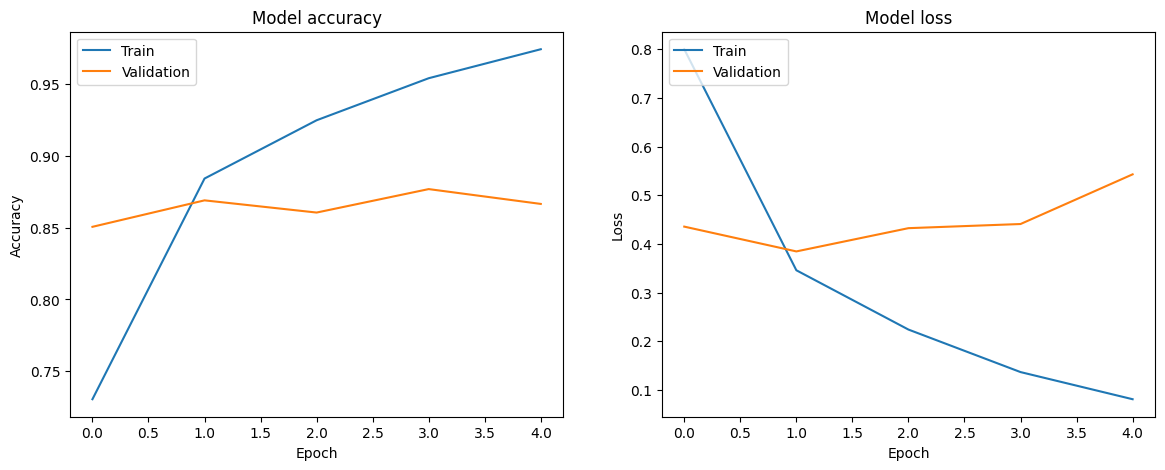

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()